In [1]:
import os
os.chdir(os.path.dirname(os.getcwd()))

In [40]:
import polars as pl
import numpy as np
def dummy_npwarn_decorator_factory():
  def npwarn_decorator(x):
    return x
  return npwarn_decorator
np._no_nep50_warning = getattr(np, '_no_nep50_warning', dummy_npwarn_decorator_factory)
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import pearsonr
from tqdm import tqdm

In [3]:
# Constants
H = 1
dm = 1941
ptmax = 730

# Paths
path = 'data/m5-forecasting-accuracy/'

# Load CSVs
calendar = pl.read_csv(f"{path}calendar.csv", try_parse_dates=True)
selling_prices = pl.read_csv(f"{path}sell_prices.csv")
sample_submission = pl.read_csv(f"{path}sample_submission.csv")
sales = pl.read_csv(f"{path}sales_train_evaluation.csv")

In [4]:
calendar

date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
date,i64,str,i64,i64,i64,str,str,str,str,str,i64,i64,i64
2011-01-29,11101,"""Saturday""",1,1,2011,"""d_1""",null,null,null,null,0,0,0
2011-01-30,11101,"""Sunday""",2,1,2011,"""d_2""",null,null,null,null,0,0,0
2011-01-31,11101,"""Monday""",3,1,2011,"""d_3""",null,null,null,null,0,0,0
2011-02-01,11101,"""Tuesday""",4,2,2011,"""d_4""",null,null,null,null,1,1,0
2011-02-02,11101,"""Wednesday""",5,2,2011,"""d_5""",null,null,null,null,1,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2016-06-15,11620,"""Wednesday""",5,6,2016,"""d_1965""",null,null,null,null,0,1,1
2016-06-16,11620,"""Thursday""",6,6,2016,"""d_1966""",null,null,null,null,0,0,0
2016-06-17,11620,"""Friday""",7,6,2016,"""d_1967""",null,null,null,null,0,0,0


In [5]:
# === Calendar Preprocessing ===
calendar = (
    calendar.with_columns([
        pl.col("date").dt.day().alias("dayofmonth"),
        pl.col("d").cast(pl.String).str.replace("d_", "").cast(pl.Int32)
    ])
)

for col in ["event_name_1", "event_type_1"]:
    if col in calendar.columns:
        calendar = calendar.with_columns(pl.col(col).cast(pl.Categorical))

In [6]:
calendar

date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,dayofmonth
date,i64,str,i64,i64,i64,i32,cat,cat,str,str,i64,i64,i64,i8
2011-01-29,11101,"""Saturday""",1,1,2011,1,null,null,null,null,0,0,0,29
2011-01-30,11101,"""Sunday""",2,1,2011,2,null,null,null,null,0,0,0,30
2011-01-31,11101,"""Monday""",3,1,2011,3,null,null,null,null,0,0,0,31
2011-02-01,11101,"""Tuesday""",4,2,2011,4,null,null,null,null,1,1,0,1
2011-02-02,11101,"""Wednesday""",5,2,2011,5,null,null,null,null,1,0,1,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2016-06-15,11620,"""Wednesday""",5,6,2016,1965,null,null,null,null,0,1,1,15
2016-06-16,11620,"""Thursday""",6,6,2016,1966,null,null,null,null,0,0,0,16
2016-06-17,11620,"""Friday""",7,6,2016,1967,null,null,null,null,0,0,0,17


In [7]:
# === Selling Prices Preprocessing ===
selling_prices = selling_prices.sort(by=["store_id", "item_id", "wm_yr_wk"])
selling_prices = selling_prices.with_columns([
    (pl.col("sell_price") / pl.col("sell_price").shift(1) - 1)
        .over(["store_id", "item_id"])
        .alias("sell_price_rel_diff"),

    ((pl.col("sell_price") - pl.col("sell_price").cum_min()) /
     (1 + pl.col("sell_price").cum_max() - pl.col("sell_price").cum_min()))
        .over(["store_id", "item_id"])
        .alias("sell_price_cumrel"),

    pl.col("sell_price")
        .rolling_std(window_size=7)
        .over(["store_id", "item_id"])
        .alias("sell_price_roll_sd7")
])

# === Sales Reshape and Extend ===
sales = sales.with_columns(
    pl.col("id").str.replace("_validation", "", literal=True)
)

In [8]:
# Add empty future horizon columns
future_cols = [f"d_{dm + i + 1}" for i in range(H)]
for col in future_cols:
    # Cast nulls to the same type as other demand columns (likely Int32 or Float64)
    sales = sales.with_columns(pl.lit(None).cast(pl.Float64).alias(col))

# Melt to long format
id_vars = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
sales = sales.melt(id_vars=id_vars, variable_name="d", value_name="demand")
sales = sales.with_columns(pl.col("d").str.replace("d_", "").cast(pl.Int32))

# === Trim old rows ===
sales = sales.filter(pl.col("d") >= dm - ptmax - 375)
calendar = calendar.filter(pl.col("d") >= dm - ptmax - 375)


/var/folders/y0/x4h3jn3n1fb8xx5p0h2h2sqc0000gn/T/ipykernel_36202/4051378879.py:9: DeprecationWarning: `DataFrame.melt` is deprecated. Use `unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  sales = sales.melt(id_vars=id_vars, variable_name="d", value_name="demand")


In [13]:
# === Encode categorical variables ===
cat_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
for col in cat_cols:
    sales = sales.with_columns(pl.col(col).cast(pl.Categorical))

# === Trim for training ===
sales = sales.filter(pl.col("d") > dm - ptmax - 375)
calendar = calendar.filter(pl.col("d") > dm - ptmax - 375)

In [14]:
# --- Step 2: Define constants
n_item = 3049
n_stores = 10
n_all = n_item * n_stores
n_dates = 1941

# --- Step 3: Filter a subset of items (optional step in R)
# This matches the logic: iitem_id <- which(tmp  %in% tmp[1:n_item][iitem])
unique_items = sales.select("item_id").unique().to_series()
selected_items = unique_items[:n_item]  # Equivalent to iitem <- 1:n_item

sales = sales.filter(pl.col("item_id").is_in(selected_items))

# --- Step 4: Aggregate demand features
sales = sales.with_columns([
    pl.col("demand").mean().over(["store_id", "d"]).alias("demand_store_id"),
    pl.col("demand").mean().over(["item_id", "d"]).alias("demand_item_id"),
    pl.col("demand").mean().over("d").alias("demand_all_id")
])

# --- (Optional) Show a sample
sales.select([
    "demand", "item_id", "store_id", "d",
    "demand_store_id", "demand_item_id", "demand_all_id"
]).head(30)

demand,item_id,store_id,d,demand_store_id,demand_item_id,demand_all_id
f64,cat,cat,i32,f64,f64,f64
0.0,"""HOBBIES_1_001""","""CA_1""",837,1.168908,0.0,1.07855
0.0,"""HOBBIES_1_002""","""CA_1""",837,1.168908,0.1,1.07855
0.0,"""HOBBIES_1_003""","""CA_1""",837,1.168908,0.0,1.07855
3.0,"""HOBBIES_1_004""","""CA_1""",837,1.168908,1.6,1.07855
1.0,"""HOBBIES_1_005""","""CA_1""",837,1.168908,0.8,1.07855
…,…,…,…,…,…,…
0.0,"""HOBBIES_1_026""","""CA_1""",837,1.168908,0.2,1.07855
0.0,"""HOBBIES_1_027""","""CA_1""",837,1.168908,0.0,1.07855
0.0,"""HOBBIES_1_028""","""CA_1""",837,1.168908,0.3,1.07855


In [15]:
lags_demand = [H, H+1, H+6]
lags_store = [H, H+1, H+6]
lags_annual = [52 * 7]

# Lag features for demand
for lag in lags_demand:
    colname = f"demand_lag_tH" if lag == H else f"demand_lag_tHp{lag - H}"
    sales = sales.with_columns(
        pl.col("demand").shift(lag).over("id").alias(colname)
    )

sales = sales.with_columns(
    pl.col("demand").shift(52 * 7).over("id").alias("demand_lag_ann7")
)

# Rolling means for demand lags
sales = sales.with_columns([
    pl.col("demand_lag_tH").rolling_mean(7).over("id").alias("demand_rolling_mean_t7"),
    pl.col("demand_lag_tH").rolling_mean(14).over("id").alias("demand_rolling_mean_t14"),
    pl.col("demand_lag_tH").rolling_mean(28).over("id").alias("demand_rolling_mean_t28"),
    pl.col("demand_lag_tH").rolling_mean(56).over("id").alias("demand_rolling_mean_t56"),
    pl.col("demand_lag_ann7").rolling_mean(7).over("id").alias("demand_rolling_mean_ann7")
])

In [17]:
# Lag features for demand_store_id
for lag in lags_store:
    colname = f"demand_store_id_lag_tH" if lag == H else f"demand_store_id_lag_tHp{lag - H}"
    sales = sales.with_columns(
        pl.col("demand_store_id").shift(lag).over("id").alias(colname)
    )

sales = sales.with_columns(
    pl.col("demand_store_id").shift(52 * 7).over("id").alias("demand_store_id_lag_ann7")
)

# Rolling means for demand_store_id lags
sales = sales.with_columns([
    pl.col("demand_store_id_lag_tH").rolling_mean(7).over("id").alias("demand_store_id_rolling_mean_t7"),
    pl.col("demand_store_id_lag_tH").rolling_mean(14).over("id").alias("demand_store_id_rolling_mean_t14"),
    pl.col("demand_store_id_lag_tH").rolling_mean(28).over("id").alias("demand_store_id_rolling_mean_t28"),
    pl.col("demand_store_id_lag_tH").rolling_mean(56).over("id").alias("demand_store_id_rolling_mean_t56"),
    pl.col("demand_store_id_lag_ann7").rolling_mean(7).over("id").alias("demand_store_id_rolling_mean_ann7")
])

In [18]:

annual_lag = 52 * 7

# ---- demand_item_id lags ----
sales = sales.with_columns([
    pl.col("demand_item_id").shift(H).over("id").alias("demand_item_id_lag_tH"),
    pl.col("demand_item_id").shift(H + 1).over("id").alias("demand_item_id_lag_tHp1"),
    pl.col("demand_item_id").shift(H + 6).over("id").alias("demand_item_id_lag_tHp6"),
    pl.col("demand_item_id").shift(annual_lag).over("id").alias("demand_item_id_lag_ann7")
])

# Rolling means for demand_item_id
sales = sales.with_columns([
    pl.col("demand_item_id_lag_tH").rolling_mean(7).over("id").alias("demand_item_id_rolling_mean_t7"),
    pl.col("demand_item_id_lag_tH").rolling_mean(14).over("id").alias("demand_item_id_rolling_mean_t14"),
    pl.col("demand_item_id_lag_tH").rolling_mean(28).over("id").alias("demand_item_id_rolling_mean_t28"),
    pl.col("demand_item_id_lag_tH").rolling_mean(56).over("id").alias("demand_item_id_rolling_mean_t56"),
    pl.col("demand_item_id_lag_ann7").rolling_mean(7).over("id").alias("demand_item_id_rolling_mean_ann7")
])

# ---- demand_all_id lags ----
sales = sales.with_columns([
    pl.col("demand_all_id").shift(H).over("id").alias("demand_all_id_lag_tH"),
    pl.col("demand_all_id").shift(H + 1).over("id").alias("demand_all_id_lag_tHp1"),
    pl.col("demand_all_id").shift(H + 6).over("id").alias("demand_all_id_lag_tHp6"),
    pl.col("demand_all_id").shift(annual_lag).over("id").alias("demand_all_id_lag_ann7")
])

# Rolling means for demand_all_id
sales = sales.with_columns([
    pl.col("demand_all_id_lag_tH").rolling_mean(7).over("id").alias("demand_all_id_rolling_mean_t7"),
    pl.col("demand_all_id_lag_tH").rolling_mean(14).over("id").alias("demand_all_id_rolling_mean_t14"),
    pl.col("demand_all_id_lag_tH").rolling_mean(28).over("id").alias("demand_all_id_rolling_mean_t28"),
    pl.col("demand_all_id_lag_tH").rolling_mean(56).over("id").alias("demand_all_id_rolling_mean_t56"),
    pl.col("demand_all_id_lag_ann7").rolling_mean(7).over("id").alias("demand_all_id_rolling_mean_ann7")
])

In [20]:
selling_prices.columns

['store_id',
 'item_id',
 'wm_yr_wk',
 'sell_price',
 'sell_price_rel_diff',
 'sell_price_cumrel',
 'sell_price_roll_sd7']

In [21]:
sales.columns

['id',
 'item_id',
 'dept_id',
 'cat_id',
 'store_id',
 'state_id',
 'd',
 'demand',
 'demand_store_id',
 'demand_item_id',
 'demand_all_id',
 'demand_lag_tH',
 'demand_lag_tHp1',
 'demand_lag_tHp6',
 'demand_lag_ann7',
 'demand_rolling_mean_t7',
 'demand_rolling_mean_t14',
 'demand_rolling_mean_t28',
 'demand_rolling_mean_t56',
 'demand_rolling_mean_ann7',
 'demand_store_id_lag_tH',
 'demand_store_id_lag_tHp1',
 'demand_store_id_lag_tHp6',
 'demand_store_id_lag_ann7',
 'demand_store_id_rolling_mean_t7',
 'demand_store_id_rolling_mean_t14',
 'demand_store_id_rolling_mean_t28',
 'demand_store_id_rolling_mean_t56',
 'demand_store_id_rolling_mean_ann7',
 'demand_item_id_lag_tH',
 'demand_item_id_lag_tHp1',
 'demand_item_id_lag_tHp6',
 'demand_item_id_lag_ann7',
 'demand_item_id_rolling_mean_t7',
 'demand_item_id_rolling_mean_t14',
 'demand_item_id_rolling_mean_t28',
 'demand_item_id_rolling_mean_t56',
 'demand_item_id_rolling_mean_ann7',
 'demand_all_id_lag_tH',
 'demand_all_id_lag_tHp1',

In [22]:
# Step 1: Filter where at least one of the rolling means is not null
sales = sales.filter(
    pl.col("demand_rolling_mean_ann7").is_not_null() | 
    pl.col("demand_rolling_mean_t28").is_not_null()
)

# Step 2: Merge calendar on 'd'
sales = sales.join(calendar, on="d", how="left")

# Step 3: Add idn column
sales = sales.with_columns(pl.col("id").alias("idn"))

# Step 4: Convert store_id and item_id in selling_prices to categorical to match sales
selling_prices = selling_prices.with_columns([
    pl.col("store_id").cast(pl.Categorical),
    pl.col("item_id").cast(pl.Categorical)
])

# Step 5: Merge with selling_prices on keys
train = sales.join(selling_prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

# Step 5: Drop wm_yr_wk
train = train.drop("wm_yr_wk")

/var/folders/y0/x4h3jn3n1fb8xx5p0h2h2sqc0000gn/T/ipykernel_36202/984616666.py:20: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance
  train = sales.join(selling_prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")


In [23]:
train

id,item_id,dept_id,cat_id,store_id,state_id,d,demand,demand_store_id,demand_item_id,demand_all_id,demand_lag_tH,demand_lag_tHp1,demand_lag_tHp6,demand_lag_ann7,demand_rolling_mean_t7,demand_rolling_mean_t14,demand_rolling_mean_t28,demand_rolling_mean_t56,demand_rolling_mean_ann7,demand_store_id_lag_tH,demand_store_id_lag_tHp1,demand_store_id_lag_tHp6,demand_store_id_lag_ann7,demand_store_id_rolling_mean_t7,demand_store_id_rolling_mean_t14,demand_store_id_rolling_mean_t28,demand_store_id_rolling_mean_t56,demand_store_id_rolling_mean_ann7,demand_item_id_lag_tH,demand_item_id_lag_tHp1,demand_item_id_lag_tHp6,demand_item_id_lag_ann7,demand_item_id_rolling_mean_t7,demand_item_id_rolling_mean_t14,demand_item_id_rolling_mean_t28,demand_item_id_rolling_mean_t56,…,demand_all_id_rolling_mean_t7,demand_all_id_rolling_mean_t14,demand_all_id_rolling_mean_t28,demand_all_id_rolling_mean_t56,demand_all_id_rolling_mean_ann7,date,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,dayofmonth,idn,date_right,wm_yr_wk_right,weekday_right,wday_right,month_right,year_right,event_name_1_right,event_type_1_right,event_name_2_right,event_type_2_right,snap_CA_right,snap_TX_right,snap_WI_right,dayofmonth_right,sell_price,sell_price_rel_diff,sell_price_cumrel,sell_price_roll_sd7
cat,cat,cat,cat,cat,cat,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,date,str,i64,i64,i64,cat,cat,str,str,i64,i64,i64,i8,cat,date,i64,str,i64,i64,i64,cat,cat,str,str,i64,i64,i64,i8,f64,f64,f64,f64
"""HOBBIES_1_001_CA_1_evaluation""","""HOBBIES_1_001""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",865,0.0,1.265661,0.0,1.135618,0.0,0.0,0.0,null,0.0,0.0,0.0,null,null,1.532306,1.997704,1.265005,null,1.515204,1.478072,1.416108,null,null,0.0,0.0,0.0,null,0.0,0.0,0.0,null,…,1.270056,1.225458,1.184271,null,null,2013-06-11,"""Tuesday""",4,6,2013,null,null,null,null,0,1,1,11,"""HOBBIES_1_001_CA_1_evaluation""",2013-06-11,11320,"""Tuesday""",4,6,2013,null,null,null,null,0,1,1,11,null,null,null,null
"""HOBBIES_1_002_CA_1_evaluation""","""HOBBIES_1_002""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",865,0.0,1.265661,0.2,1.135618,0.0,0.0,1.0,null,0.285714,0.214286,0.214286,null,null,1.532306,1.997704,1.265005,null,1.515204,1.478072,1.416108,null,null,0.1,0.1,0.6,null,0.257143,0.35,0.278571,null,…,1.270056,1.225458,1.184271,null,null,2013-06-11,"""Tuesday""",4,6,2013,null,null,null,null,0,1,1,11,"""HOBBIES_1_002_CA_1_evaluation""",2013-06-11,11320,"""Tuesday""",4,6,2013,null,null,null,null,0,1,1,11,3.97,0.0,0.0,0.0
"""HOBBIES_1_003_CA_1_evaluation""","""HOBBIES_1_003""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",865,0.0,1.265661,0.0,1.135618,0.0,0.0,0.0,null,0.0,0.0,0.0,null,null,1.532306,1.997704,1.265005,null,1.515204,1.478072,1.416108,null,null,0.0,0.0,0.0,null,0.0,0.0,0.0,null,…,1.270056,1.225458,1.184271,null,null,2013-06-11,"""Tuesday""",4,6,2013,null,null,null,null,0,1,1,11,"""HOBBIES_1_003_CA_1_evaluation""",2013-06-11,11320,"""Tuesday""",4,6,2013,null,null,null,null,0,1,1,11,null,null,null,null
"""HOBBIES_1_004_CA_1_evaluation""","""HOBBIES_1_004""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",865,1.0,1.265661,3.0,1.135618,1.0,0.0,0.0,null,0.714286,1.285714,1.571429,null,null,1.532306,1.997704,1.265005,null,1.515204,1.478072,1.416108,null,null,2.4,2.7,1.7,null,2.328571,2.378571,2.346429,null,…,1.270056,1.225458,1.184271,null,null,2013-06-11,"""Tuesday""",4,6,2013,null,null,null,null,0,1,1,11,"""HOBBIES_1_004_CA_1_evaluation""",2013-06-11,11320,"""Tuesday""",4,6,2013,null,null,null,null,0,1,1,11,4.64,0.0,0.230769,1.7004e-8
"""HOBBIES_1_005_CA_1_evaluation""","""HOBBIES_1_005""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",865,1.0,1.265661,0.8,1.135618,1.0,2.0,0.0,null,1.0,0.5,1.071429,null,null,1.532306,1.997704,1.265005,null,1.515204,1.478072,1.416108,null,null,0.4,0.7,1.2,null,0.628571,0.657143,0.785714,null,…,1.

In [27]:
categorical_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

for col in categorical_cols:
    if train[col].dtype == pl.Categorical:
        train = train.with_columns(
            pl.col(col).cast(pl.Utf8).rank(method="dense").cast(pl.Int32).alias(col)
        )

In [29]:
# Step 1: Filter rows after (dm - ptmax)
train = train.filter(pl.col("d") > dm - ptmax)

# Step 2: Remove rows between max(d)-H and max(d)
d_max = train.select(pl.col("d").max()).item()  # extract scalar from polars result

train = train.filter(
    ~((pl.col("d") < d_max) & (pl.col("d") > d_max - H))
)
train

id,item_id,dept_id,cat_id,store_id,state_id,d,demand,demand_store_id,demand_item_id,demand_all_id,demand_lag_tH,demand_lag_tHp1,demand_lag_tHp6,demand_lag_ann7,demand_rolling_mean_t7,demand_rolling_mean_t14,demand_rolling_mean_t28,demand_rolling_mean_t56,demand_rolling_mean_ann7,demand_store_id_lag_tH,demand_store_id_lag_tHp1,demand_store_id_lag_tHp6,demand_store_id_lag_ann7,demand_store_id_rolling_mean_t7,demand_store_id_rolling_mean_t14,demand_store_id_rolling_mean_t28,demand_store_id_rolling_mean_t56,demand_store_id_rolling_mean_ann7,demand_item_id_lag_tH,demand_item_id_lag_tHp1,demand_item_id_lag_tHp6,demand_item_id_lag_ann7,demand_item_id_rolling_mean_t7,demand_item_id_rolling_mean_t14,demand_item_id_rolling_mean_t28,demand_item_id_rolling_mean_t56,…,demand_all_id_rolling_mean_t7,demand_all_id_rolling_mean_t14,demand_all_id_rolling_mean_t28,demand_all_id_rolling_mean_t56,demand_all_id_rolling_mean_ann7,date,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,dayofmonth,idn,date_right,wm_yr_wk_right,weekday_right,wday_right,month_right,year_right,event_name_1_right,event_type_1_right,event_name_2_right,event_type_2_right,snap_CA_right,snap_TX_right,snap_WI_right,dayofmonth_right,sell_price,sell_price_rel_diff,sell_price_cumrel,sell_price_roll_sd7
i32,i32,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,date,str,i64,i64,i64,cat,cat,str,str,i64,i64,i64,i8,cat,date,i64,str,i64,i64,i64,cat,cat,str,str,i64,i64,i64,i8,f64,f64,f64,f64
14371,1438,4,2,1,1,1212,0.0,1.527714,0.2,1.25897,1.0,0.0,1.0,0.0,0.714286,0.428571,0.321429,0.321429,0.0,1.285011,1.126271,1.653329,1.563135,1.336176,1.34735,1.408799,1.434686,1.376001,0.3,0.0,0.5,0.0,0.257143,0.3,0.307143,0.323214,…,1.11593,1.152345,1.173936,1.197962,1.127611,2014-05-24,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,"""HOBBIES_1_001_CA_1_evaluation""",2014-05-24,11417,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,8.26,0.0,0.0,1.8250e-8
14381,1439,4,2,1,1,1212,2.0,1.527714,0.4,1.25897,0.0,2.0,1.0,0.0,0.571429,0.357143,0.321429,0.285714,0.142857,1.285011,1.126271,1.653329,1.563135,1.336176,1.34735,1.408799,1.434686,1.376001,0.1,0.2,0.3,0.0,0.271429,0.228571,0.232143,0.191071,…,1.11593,1.152345,1.173936,1.197962,1.127611,2014-05-24,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,"""HOBBIES_1_002_CA_1_evaluation""",2014-05-24,11417,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,3.97,0.0,0.0,0.0
14391,1440,4,2,1,1,1212,0.0,1.527714,0.2,1.25897,0.0,0.0,0.0,0.0,0.142857,0.142857,0.178571,0.267857,0.0,1.285011,1.126271,1.653329,1.563135,1.336176,1.34735,1.408799,1.434686,1.376001,0.1,0.0,0.3,0.0,0.114286,0.085714,0.103571,0.1125,…,1.11593,1.152345,1.173936,1.197962,1.127611,2014-05-24,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,"""HOBBIES_1_003_CA_1_evaluation""",2014-05-24,11417,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,2.97,0.0,0.0,0.0
14401,1441,4,2,1,1,1212,2.0,1.527714,1.7,1.25897,1.0,2.0,6.0,1.0,2.428571,2.357143,2.357143,2.321429,1.428571,1.285011,1.126271,1.653329,1.563135,1.336176,1.34735,1.408799,1.434686,1.376001,3.9,1.9,2.7,3.1,2.642857,2.385714,2.385714,2.4625,…,1.11593,1.152345,1.173936,1.197962,1.127611,2014-05-24,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,"""HOBBIES_1_004_CA_1_evaluation""",2014-05-24,11417,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,4.64,0.0,0.230769,1.7004e-8
14411,1442,4,2,1,1,1212,1.0,1.527714,0.5,1.25897,2.0,1.0,1.0,3.0,1.142857,1.214286,0.892857,0.821429,2.0,1.285011,1.126271,1.653329,1.563135,1.336176,1.34735,1.408799,1.434686,1.376001,0.2,0.5,0.4,1.2,0.4,0.45,0.528571,0.532143,…,1.11593,1.152345,1.173936,1.197962,1.127611,2014-05-24,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,"""HOBBIES_1_005_CA_1_evaluation""",2014-05-24,11417,"""Saturday""",1,5,2014,null,null,null,null,0,0,0,24,3.08,0.0,0.375,1.3302e-8
…,…,…,…,…,…,…,…,

In [33]:
# Constants
n_item = 3049
n_stores = 10
n_all = n_item * n_stores
H = 1  # forecast horizon
ptmax = 730  # or 1941
train = train.sort("d")  # make sure time is ordered

In [116]:
# --- Summary statistics ---
OO_rows = []

# Get time step indices for the first time series
first_id = train[0, "id"]
idp = train.filter(pl.col("id") == first_id).select("d").to_series().to_numpy()
idp = idp - idp.min()  # Offset pattern

for ii in tqdm(range(n_all), desc="Building OO summary features"):

    row = {}

    idx = idp + ii  # Index time steps for this series
    if idx.max() >= len(train):
        continue  # Skip if out of bounds

    # Subset this time series
    ts_row = train[idx]

    # Filter out entries with missing sell_price
    sp = ts_row.select("sell_price").to_series().to_numpy()
    valid_mask = ~np.isnan(sp)
    if not valid_mask.any():
        continue

    ts_row = ts_row.filter(valid_mask)

    # Extract values
    item_id = ts_row[0, "item_id"]
    store_id = ts_row[0, "store_id"]
    yy = ts_row["demand"].to_numpy()
    yya = ts_row["demand_rolling_mean_ann7"].to_numpy()

    # Drop NA demand values
    mask = ~np.isnan(yy)
    yy = yy[mask]
    yya = yya[mask]

    if len(yy) == 0:
        continue

    # Basic metadata
    row["item_id"] = item_id
    row["store_id"] = store_id
    row["n"] = len(yy)
    row["min"] = np.min(yy)
    row["max"] = np.max(yy)
    row["mean"] = np.mean(yy)
    row["sd"] = np.std(yy, ddof=1)
    row["z0"] = np.mean(yy == 0)
    row["z1"] = np.mean(yy == 1)

    # ACF & PACF
    try:
        yacf = acf(yy, nlags=7, fft=False)[1:]
        ypacf = pacf(yy, nlags=7)[1:]
        row["acf1"] = yacf[0]
        row["acf7"] = yacf[6]
        row["pacf7"] = ypacf[6]
    except Exception:
        row["acf1"] = row["acf7"] = row["pacf7"] = 0

    # Annual autocorrelation
    try:
        corr = pearsonr(yya, yy)[0]
        row["acann7"] = 0 if np.isnan(corr) else corr
    except Exception:
        row["acann7"] = 0

    # Append to result
    OO_rows.append(row)

# --- Convert to Polars DataFrame ---
OO = pl.DataFrame(OO_rows).fill_null(0)

# Optionally save
OO.write_parquet("data/m5-forecasting-accuracy/OO.parquet")


Building OO summary features: 100%|██████████| 30490/30490 [00:17<00:00, 1733.37it/s]


In [117]:
# Step 1: Compute average over stores per item
OOO = (OO.group_by("item_id", maintain_order=True)
    .agg([
        pl.mean("n").alias("n"),
        pl.mean("mean").alias("mean"),
        pl.mean("sd").alias("sd"),
        pl.mean("acf1").alias("acf1"),
        pl.mean("pacf7").alias("pacf7"),
        pl.mean("acann7").alias("acann7"),
        pl.mean("z0").alias("z0")
    ])
    .fill_null(0)
)

In [118]:
OOO

item_id,n,mean,sd,acf1,pacf7,acann7,z0
i64,f64,f64,f64,f64,f64,f64,f64
1438,695.214286,0.80725,2.11168,0.049773,0.013121,0.568239,0.688475
1439,695.6,0.805973,2.095115,0.044239,0.011958,0.570419,0.68712
1440,696.333333,0.758618,2.003504,0.040083,0.012385,0.570312,0.696055
1441,695.090909,0.850296,2.177665,0.047051,0.010716,0.571152,0.679077
1442,695.7,0.809658,2.10229,0.042928,0.011281,0.571311,0.687037
…,…,…,…,…,…,…,…
760,680.0,2.281229,5.096373,-0.010239,-0.012647,0.603818,0.481968
1030,689.5,1.572155,3.792319,0.0172,0.033885,0.657096,0.564902
1100,693.333333,1.49428,3.920067,0.024183,0.026029,0.558963,0.582652


In [119]:
XX = (
    OOO.with_columns([
        pl.col("mean").log().alias("log_mean"),
        pl.col("sd").log().alias("log_sd")
    ])
    .select([
        "n", "log_mean", "log_sd", "acf1", "pacf7", "acann7", "z0"
    ])
    .fill_nan(0)
    .fill_null(0)
)

In [120]:
XX_np = XX.to_numpy()
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

mx = 100
np.random.seed(1234)

# Scale features (standardize each column)
XX_scaled = StandardScaler().fit_transform(XX_np)

# Run k-means clustering
kmeans = KMeans(n_clusters=mx, n_init=100, max_iter=200, random_state=1234)
cmod = kmeans.fit(XX_scaled)

# Cluster assignments
cluster_labels = cmod.labels_

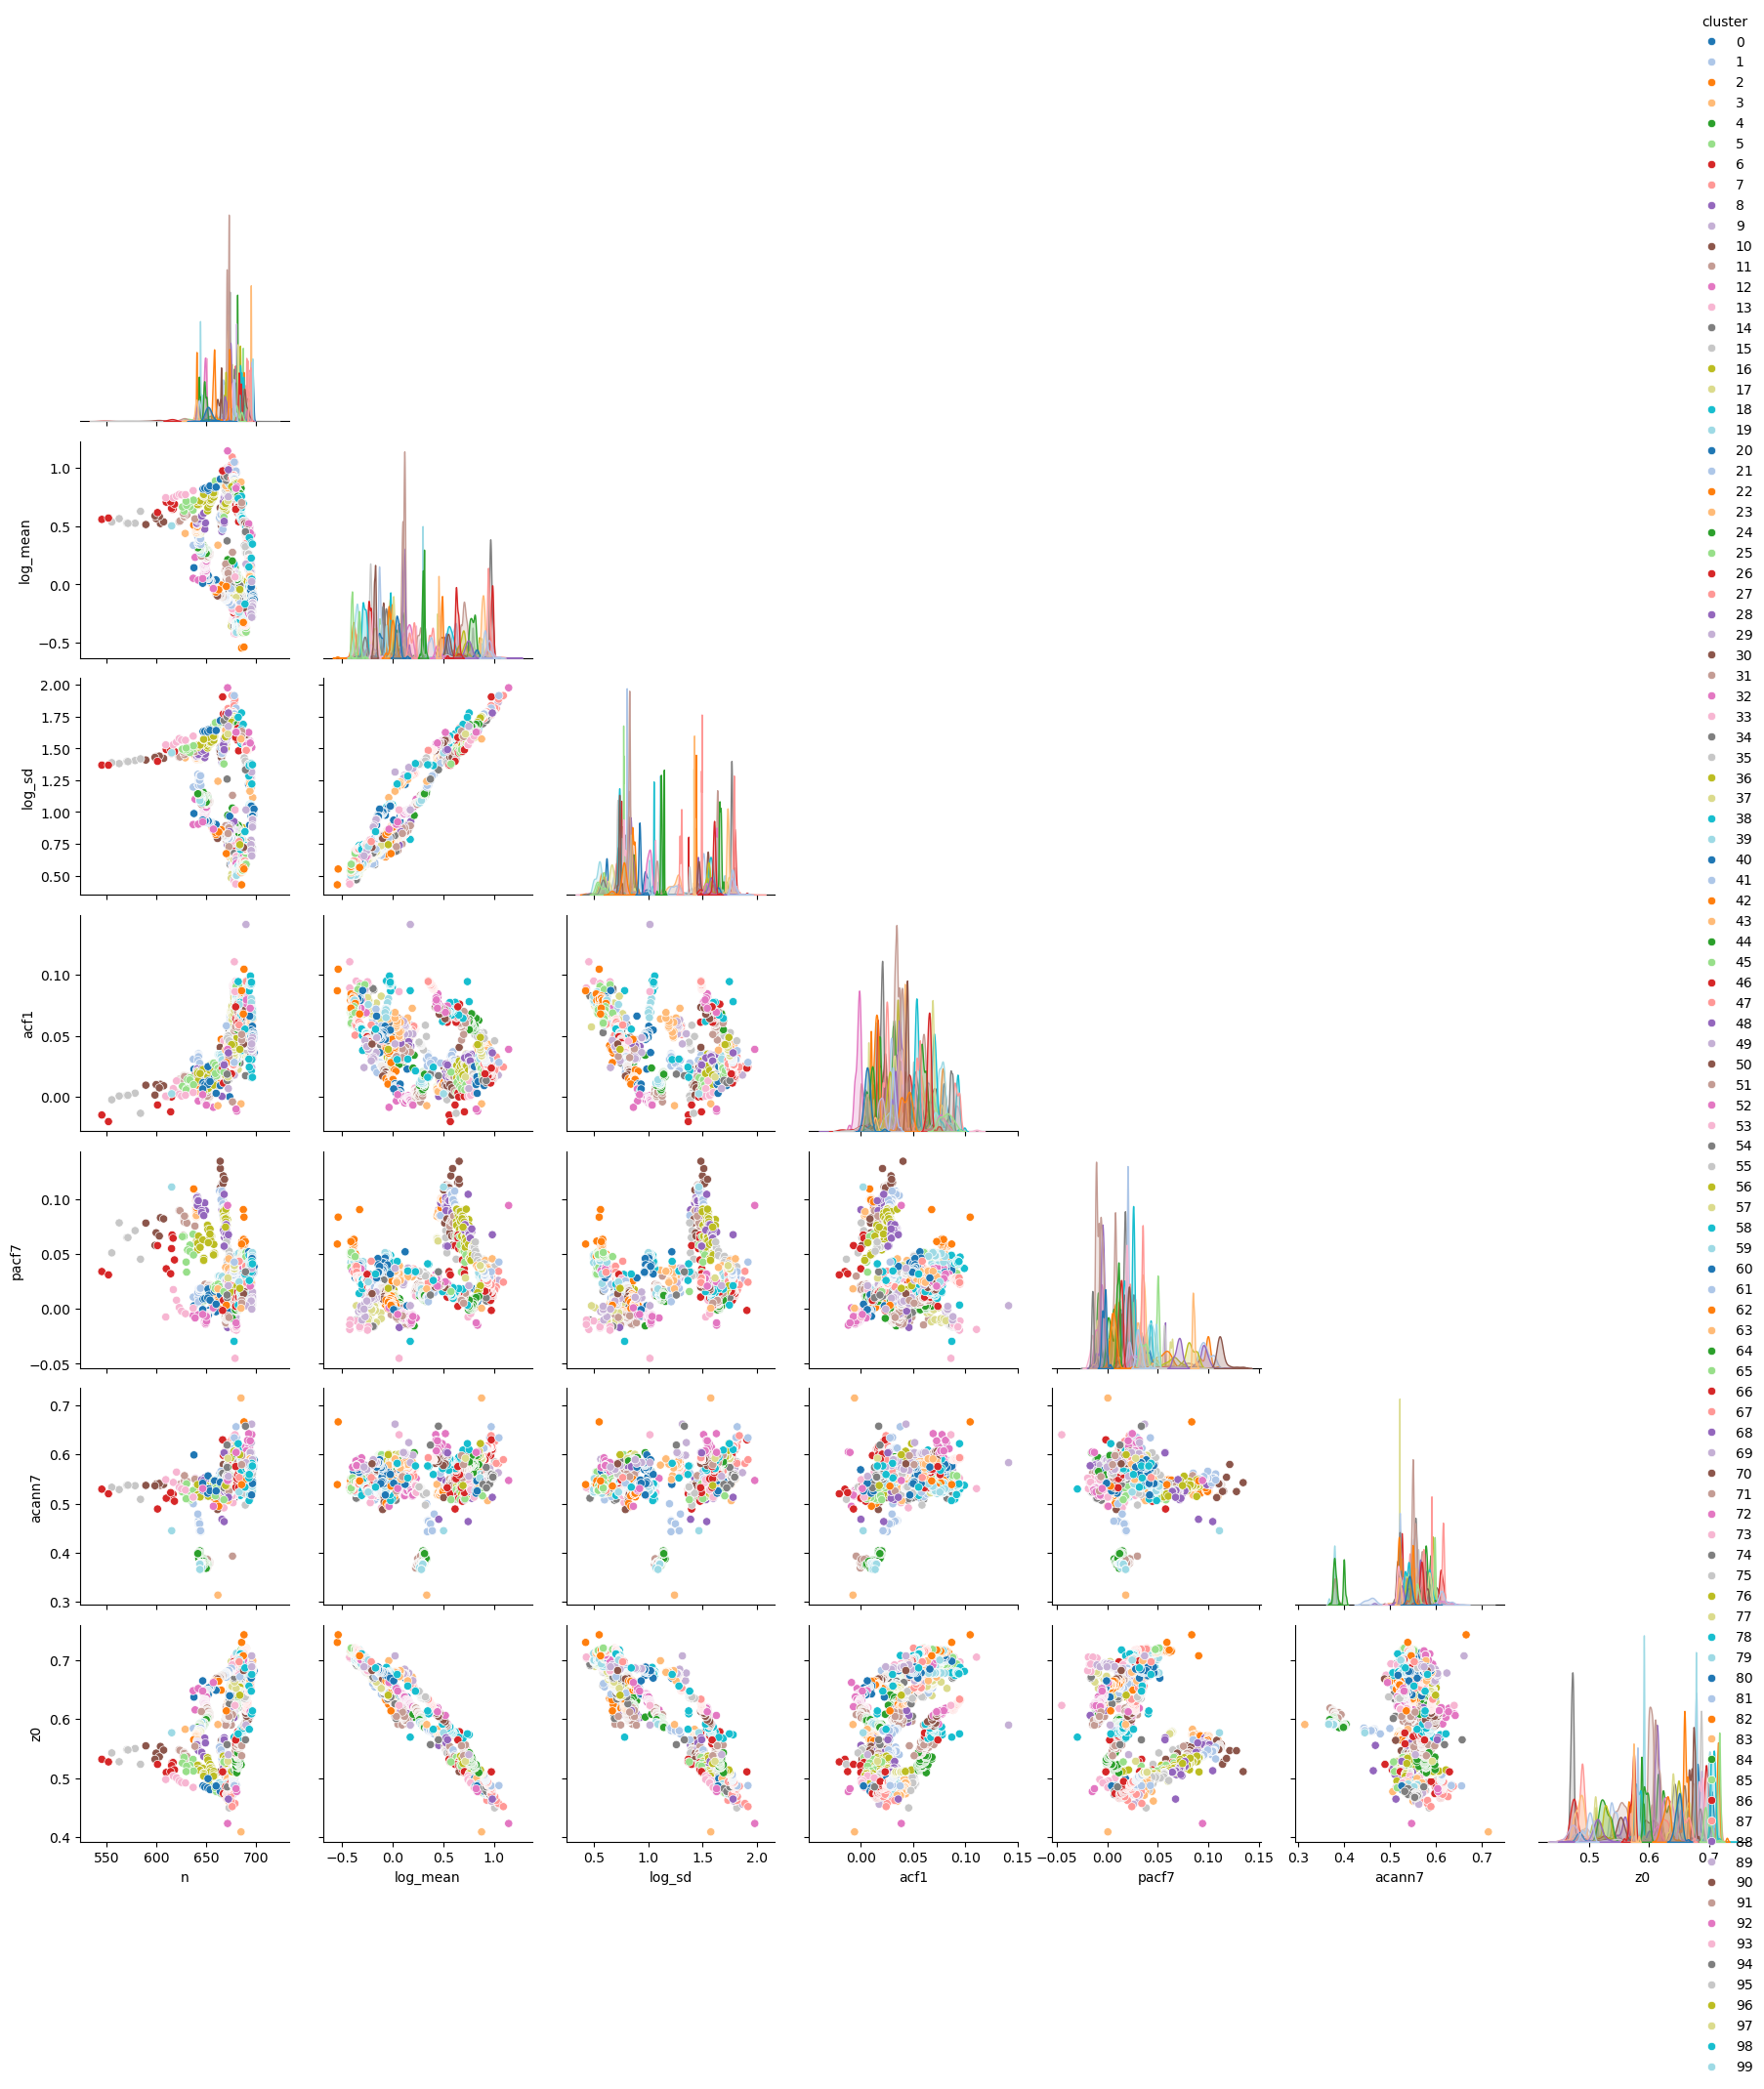

In [121]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to pandas for seaborn
df_plot = pd.DataFrame(XX, columns=["n", "log_mean", "log_sd", "acf1", "pacf7", "acann7", "z0"])
df_plot["cluster"] = cluster_labels

# Pairplot colored by cluster
sns.pairplot(df_plot, hue="cluster", palette="tab20", corner=True)
plt.tight_layout()
plt.show()

[31 31 31 42 39 24 36 24 64 97 13 61 68 47 51 10 47 54 23 15 46 29 39 40
 21 30 18 41 12 46 10 90 71 44 28 30 40 22 20 12 55 47 20 32 19 29  4 48
 26  7 26 25 46 25 10 43 15 54 34 50 43 46 31 12 19 39 34 32  7 12 22  7
 23 24 24 13 32 31 15 30  8 16 25 29 14  7 26 35 52  9  7 13 18 14 29 23
 24 41 21 30]


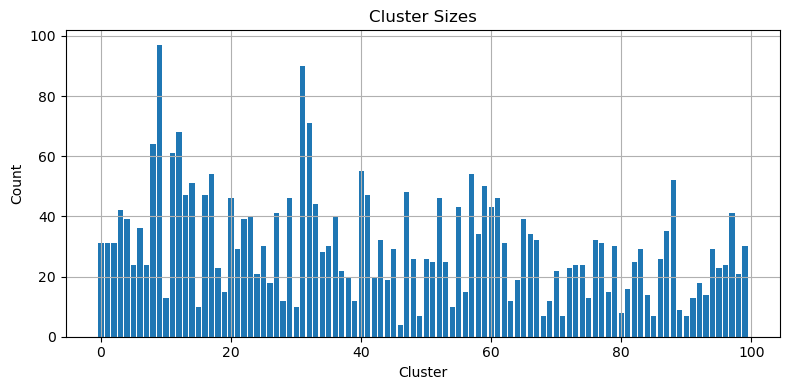

In [58]:
# Print cluster sizes
cluster_counts = np.bincount(cluster_labels)
print(cluster_counts)

# Optional: Plot
plt.figure(figsize=(8, 4))
plt.bar(np.arange(mx), cluster_counts)
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("Cluster Sizes")
plt.grid(True)
plt.tight_layout()
plt.show()